<a href="https://colab.research.google.com/github/Valery3107/BIBLIOTECA/blob/main/EDA_GENBU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐾 GENBU — Análisis Exploratorio de Datos (EDA)
## Dataset: *Dog Skin Disease Dataset* (Roboflow)

**Proyecto:** GENBU — Sistema web de apoyo al diagnóstico diferencial de dermatitis canina mediante Deep Learning.

**Autor:** Estudiante de Ingeniería de Sistemas — Proyecto de grado GENBU.

**Objetivo de este notebook:** realizar un Análisis Exploratorio de Datos (EDA) completo y riguroso sobre el dataset *Dog Skin Disease Dataset* (1.418 imágenes, 4 clases) para determinar su **viabilidad** como base de entrenamiento de un futuro modelo de clasificación de enfermedades cutáneas caninas.

> ⚠️ **Importante:** este notebook **no asume ni selecciona** una arquitectura de modelo. El EDA es un paso previo e independiente; la elección del modelo (PASO 9) se hará **después**, con base en la evidencia recolectada aquí.

**Clases del dataset:**
| Clase | Descripción |
|---|---|
| `bacterial_dermatosis` | Dermatosis de origen bacteriano |
| `fungal_infection` | Infección fúngica |
| `hypersensitivity_dermatitis` | Dermatitis por hipersensibilidad (alérgica) |
| `healthy` | Piel sana (clase control) |

**Contenido del notebook:**
1. Inspección general del dataset
2. Visualización de ejemplos por clase
3. Distribución de clases y balance
4. Tamaños y dimensiones de las imágenes
5. Análisis de canales RGB por clase
6. Detección de imágenes corruptas y duplicadas
7. Calidad y nitidez de las imágenes
8. Evaluación de viabilidad del dataset
9. Recomendaciones y criterios para la selección del modelo

---

## ⚙️ Configuración del entorno

Instalamos e importamos las librerías necesarias. **No se utiliza TensorFlow ni Keras** en este notebook: el EDA es agnóstico al framework y al modelo que se seleccione posteriormente.

In [ ]:
# Instalación de la librería de Roboflow (Google Colab no la trae preinstalada)
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 1.6 MB/s eta 0:00:00


In [ ]:
# ---------------------------------------------------------------
# Importación de librerías
# ---------------------------------------------------------------
import os
import glob
import hashlib
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Permite que PIL intente leer imágenes truncadas sin lanzar error al abrirlas
# (se usará de forma controlada en el PASO 6 para detectar corrupción real)
ImageFile.LOAD_TRUNCATED_IMAGES = False

# Configuración visual general para todas las gráficas del notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Semilla para reproducibilidad en los muestreos aleatorios
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Librerías cargadas correctamente. Entorno listo para el EDA de GENBU.")

Librerías cargadas correctamente. Entorno listo para el EDA de GENBU.


### 📥 Descarga del dataset desde Roboflow

Reemplaza `"TU_API_KEY"` por tu API Key personal de Roboflow antes de ejecutar esta celda.

In [ ]:
from roboflow import Roboflow

# --- CONFIGURA AQUÍ TU API KEY DE ROBOFLOW ---
rf = Roboflow(api_key="L7h5Q0gjhZ1iI3hsy95H")

project = rf.workspace("dog-skin-disease-dermatosis").project("dog-skin-disease-dataset")
dataset = project.version(2).download("folder")

# Ruta local donde Roboflow descargó el dataset (carpeta train/valid/test)
DATASET_PATH = dataset.location
print("Dataset descargado en:", DATASET_PATH)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Dog-Skin-Disease-Dataset-2 in folder:: 100%|██████████| 4415/4415 [00:01<00:00, 2279.72it/s]

Dataset descargado en: /content/Dog-Skin-Disease-Dataset-2


### 🌳 Estructura real de carpetas del dataset descargado

**Importante:** nunca se debe asumir de antemano cómo se llaman las carpetas de clase dentro del export de Roboflow (pueden variar en mayúsculas/minúsculas, guiones, espacios, sufijos de versión, etc.). Antes de indexar nada, imprimimos el árbol de directorios **real** tal como quedó en disco, para verificar visualmente los nombres exactos de los splits (train/valid/test) y de las clases dentro de cada uno.

In [ ]:
def imprimir_arbol(directorio, prefijo="", nivel_maximo=3, nivel_actual=0):
    '''Imprime recursivamente la estructura de carpetas de un directorio,
    mostrando cuántos archivos contiene cada subcarpeta. Limitado a
    nivel_maximo de profundidad para no saturar la salida en datasets grandes.'''
    if nivel_actual > nivel_maximo:
        return
    try:
        entradas = sorted(os.listdir(directorio))
    except (NotADirectoryError, FileNotFoundError, PermissionError):
        return

    for entrada in entradas:
        ruta = os.path.join(directorio, entrada)
        if os.path.isdir(ruta):
            n_archivos = len([f for f in os.listdir(ruta) if os.path.isfile(os.path.join(ruta, f))])
            etiqueta = f"  ({n_archivos} archivos)" if n_archivos else ""
            print(f"{prefijo}📁 {entrada}{etiqueta}")
            imprimir_arbol(ruta, prefijo + "    ", nivel_maximo, nivel_actual + 1)


print(f"Estructura de carpetas dentro de: {DATASET_PATH}\n")
imprimir_arbol(DATASET_PATH)

Estructura de carpetas dentro de: /content/Dog-Skin-Disease-Dataset-2

📁 test
    📁 bacterial dermatosis  (45 archivos)
    📁 fungal infection  (47 archivos)
    📁 healthy  (51 archivos)
    📁 hypersensitivity dermatitis  (37 archivos)
📁 train
    📁 bacterial dermatosis  (954 archivos)
    📁 fungal infection  (1053 archivos)
    📁 healthy  (1037 archivos)
    📁 hypersensitivity dermatitis  (807 archivos)
📁 valid
    📁 bacterial dermatosis  (98 archivos)
    📁 fungal infection  (101 archivos)
    📁 healthy  (98 archivos)
    📁 hypersensitivity dermatitis  (70 archivos)


### 🔎 Detección automática de splits y clases reales

En lugar de asumir nombres de clase predefinidos (`bacterial_dermatosis`, `fungal_infection`, etc.), la siguiente celda **detecta automáticamente**:

1. Qué subcarpetas de `DATASET_PATH` corresponden a un split (`train`, `valid`/`validation`/`val`, `test`).
2. Qué subcarpetas de clase existen realmente dentro de cada split.

Esto evita el problema de que una clase quede en `NaN` por una simple diferencia de nombre (mayúsculas, guiones, espacios, etc.) entre lo que el código esperaba y lo que Roboflow realmente exportó.

In [ ]:
def normalizar_nombre_clase(nombre):
    '''Normaliza el nombre de una carpeta de clase a snake_case en minúsculas,
    para tolerar variaciones de formato (espacios, guiones, mayúsculas) entre
    el nombre real exportado por Roboflow y el nombre "canónico" de la clase.'''
    return nombre.strip().lower().replace(" ", "_").replace("-", "_")


NOMBRES_SPLIT_CONOCIDOS = {"train", "valid", "validation", "val", "test"}

# Subcarpetas de primer nivel dentro de DATASET_PATH
subcarpetas_nivel1 = [d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))]

splits_detectados = [d for d in subcarpetas_nivel1 if d.lower() in NOMBRES_SPLIT_CONOCIDOS]

if not splits_detectados:
    # El export no tiene subcarpetas de split (train/valid/test):
    # las carpetas de clase están directamente bajo DATASET_PATH
    print("No se detectaron subcarpetas de split (train/valid/test).")
    print("Se asumirá que las carpetas de clase están directamente bajo DATASET_PATH.\n")
    splits_detectados = ["."]

clases_reales_por_split = {}
for split in splits_detectados:
    ruta_split = os.path.join(DATASET_PATH, split)
    clases_en_split = sorted([d for d in os.listdir(ruta_split)
                               if os.path.isdir(os.path.join(ruta_split, d))])
    clases_reales_por_split[split] = clases_en_split

print("=== Splits y clases detectados automáticamente ===")
for split, clases in clases_reales_por_split.items():
    print(f"- {split}: {clases}")

# Unión de todas las clases (normalizadas) encontradas en cualquier split.
# Esta lista REEMPLAZA cualquier suposición previa de nombres de clase.
CLASES_ESPERADAS = sorted({normalizar_nombre_clase(c)
                            for clases in clases_reales_por_split.values()
                            for c in clases})

print()
print("Clases detectadas automáticamente (normalizadas):", CLASES_ESPERADAS)

if len(CLASES_ESPERADAS) < 2:
    print("\n⚠️  ADVERTENCIA: se detectó menos de 2 clases. Revisa el árbol de carpetas impreso arriba;")
    print("    es posible que la estructura del export de Roboflow no sea la esperada.")

=== Splits y clases detectados automáticamente ===
- test: ['bacterial dermatosis', 'fungal infection', 'healthy', 'hypersensitivity dermatitis']
- train: ['bacterial dermatosis', 'fungal infection', 'healthy', 'hypersensitivity dermatitis']
- valid: ['bacterial dermatosis', 'fungal infection', 'healthy', 'hypersensitivity dermatitis']

Clases detectadas automáticamente (normalizadas): ['bacterial_dermatosis', 'fungal_infection', 'healthy', 'hypersensitivity_dermatitis']


### 🗂️ Indexado del dataset

Con los nombres reales de split y clase ya detectados, recorremos toda la estructura de directorios y construimos un **DataFrame maestro** con la ruta, la clase (normalizada), el split (train/valid/test) y el tamaño en disco de cada imagen. Este DataFrame es la base de todos los pasos siguientes.

In [ ]:
# Extensiones de imagen válidas a considerar
EXTENSIONES_VALIDAS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

registros = []

for ruta_actual, _subdirs, archivos in os.walk(DATASET_PATH):
    for archivo in archivos:
        if not archivo.lower().endswith(EXTENSIONES_VALIDAS):
            continue

        ruta_completa = os.path.join(ruta_actual, archivo)
        partes = Path(ruta_completa).parts

        # La clase corresponde al nombre (normalizado) de la carpeta contenedora
        clase = normalizar_nombre_clase(Path(ruta_completa).parent.name)

        # El split (train/valid/test) es la primera carpeta debajo de DATASET_PATH
        try:
            idx_dataset = partes.index(Path(DATASET_PATH).name)
            split = partes[idx_dataset + 1] if idx_dataset + 1 < len(partes) else "desconocido"
        except ValueError:
            split = "desconocido"

        registros.append({
            "filepath": ruta_completa,
            "clase": clase,
            "split": split,
            "tamano_bytes": os.path.getsize(ruta_completa),
        })

df = pd.DataFrame(registros)

# Nos quedamos únicamente con las clases detectadas automáticamente en el paso anterior
clases_sin_reconocer = sorted(set(df["clase"]) - set(CLASES_ESPERADAS))
if clases_sin_reconocer:
    print(f"⚠️  Carpetas encontradas que no coinciden con ninguna clase detectada: {clases_sin_reconocer}")

df = df[df["clase"].isin(CLASES_ESPERADAS)].reset_index(drop=True)

print(f"Total de imágenes indexadas: {len(df)}")
print()
print("--- Conteo de imágenes por clase (verificación de que ninguna quedó en 0/NaN) ---")
print(df["clase"].value_counts().reindex(CLASES_ESPERADAS))
df.head()

Total de imágenes indexadas: 4398

--- Conteo de imágenes por clase (verificación de que ninguna quedó en 0/NaN) ---
clase
bacterial_dermatosis           1097
fungal_infection               1201
healthy                        1186
hypersensitivity_dermatitis     914
Name: count, dtype: int64


,filepath,clase,split,tamano_bytes
0,/content/Dog-Skin-Disease-Dataset-2/test/funga...,fungal_infection,test,39450
1,/content/Dog-Skin-Disease-Dataset-2/test/funga...,fungal_infection,test,52319
2,/content/Dog-Skin-Disease-Dataset-2/test/funga...,fungal_infection,test,36891
3,/content/Dog-Skin-Disease-Dataset-2/test/funga...,fungal_infection,test,44019
4,/content/Dog-Skin-Disease-Dataset-2/test/funga...,fungal_infection,test,41837


---
## PASO 1 — Inspección general del dataset

**Objetivo:** conocer el volumen total de imágenes, su distribución por clase y por split (train/valid/test), como primer indicador de si el dataset tiene un tamaño suficiente para entrenar un modelo de clasificación.

In [ ]:
# Conteo de imágenes por clase
conteo_por_clase = df["clase"].value_counts().reindex(CLASES_ESPERADAS)

# Conteo de imágenes por clase y por split
conteo_clase_split = pd.crosstab(df["clase"], df["split"]).reindex(CLASES_ESPERADAS)

# Tabla resumen general
resumen_general = pd.DataFrame({
    "n_imagenes": conteo_por_clase,
    "porcentaje_%": (conteo_por_clase / len(df) * 100).round(2),
})

print("=== Resumen general del dataset GENBU ===")
print(f"Total de imágenes: {len(df)}")
print(f"Número de clases: {df['clase'].nunique()}")
print()
print("--- Imágenes por clase ---")
display(resumen_general)
print()
print("--- Imágenes por clase y split ---")
display(conteo_clase_split)

=== Resumen general del dataset GENBU ===
Total de imágenes: 4398
Número de clases: 4

--- Imágenes por clase ---


,n_imagenes,porcentaje_%
clase,,
bacterial_dermatosis,1097,24.94
fungal_infection,1201,27.31
healthy,1186,26.97
hypersensitivity_dermatitis,914,20.78



--- Imágenes por clase y split ---


split,test,train,valid
clase,,,
bacterial_dermatosis,45,954,98
fungal_infection,47,1053,101
healthy,51,1037,98
hypersensitivity_dermatitis,37,807,70


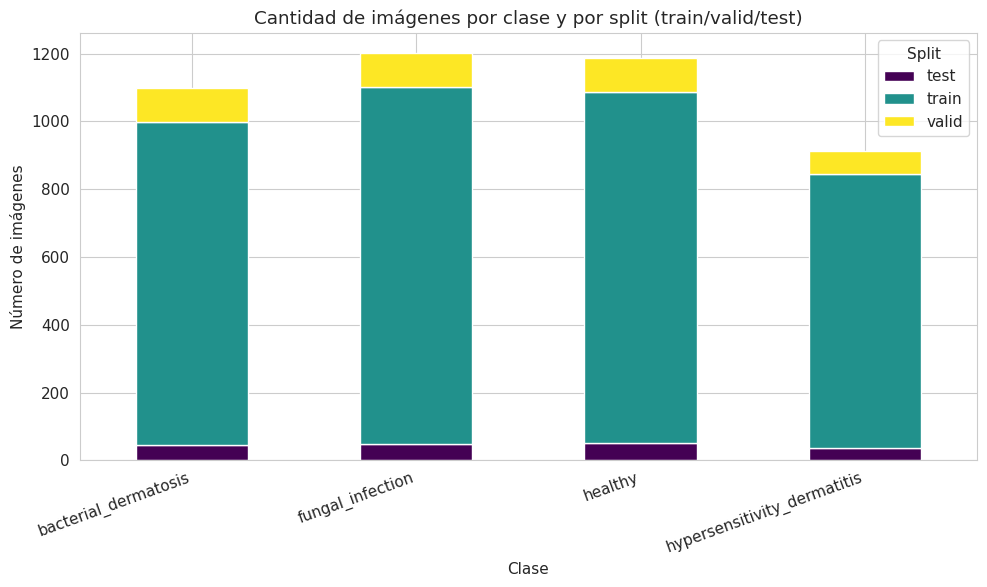

In [ ]:
# Visualización rápida del conteo por clase y split
fig, ax = plt.subplots(figsize=(10, 6))
conteo_clase_split.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Cantidad de imágenes por clase y por split (train/valid/test)")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
ax.legend(title="Split")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### ✅ Conclusión parcial — PASO 1

Como criterio orientativo para clasificación de imágenes médicas/veterinarias con *transfer learning*:

- **< 150 imágenes por clase:** volumen bajo, alto riesgo de sobreajuste; obligatorio usar aumento de datos agresivo y modelos preentrenados.
- **150 – 400 imágenes por clase:** volumen aceptable para *fine-tuning* con modelos preentrenados y regularización.
- **> 400 imágenes por clase:** volumen adecuado para *fine-tuning* robusto.

Con un total aproximado de 1.418 imágenes repartidas en 4 clases (~350 imágenes/clase en promedio), el dataset se ubica en un rango **aceptable a adecuado**, siempre que ninguna clase individual caiga muy por debajo del promedio (ver tabla `resumen_general` impresa arriba). Si alguna clase queda por debajo de 150 imágenes, esto debe registrarse como hallazgo de riesgo en el PASO 8.

---
## PASO 2 — Visualización de ejemplos por clase

**Objetivo:** inspeccionar visualmente muestras aleatorias de cada clase para verificar que el etiquetado sea coherente con el contenido real de las imágenes (por ejemplo, que las imágenes de `healthy` no muestren lesiones evidentes, o que `fungal_infection` y `bacterial_dermatosis` no estén confundidas).

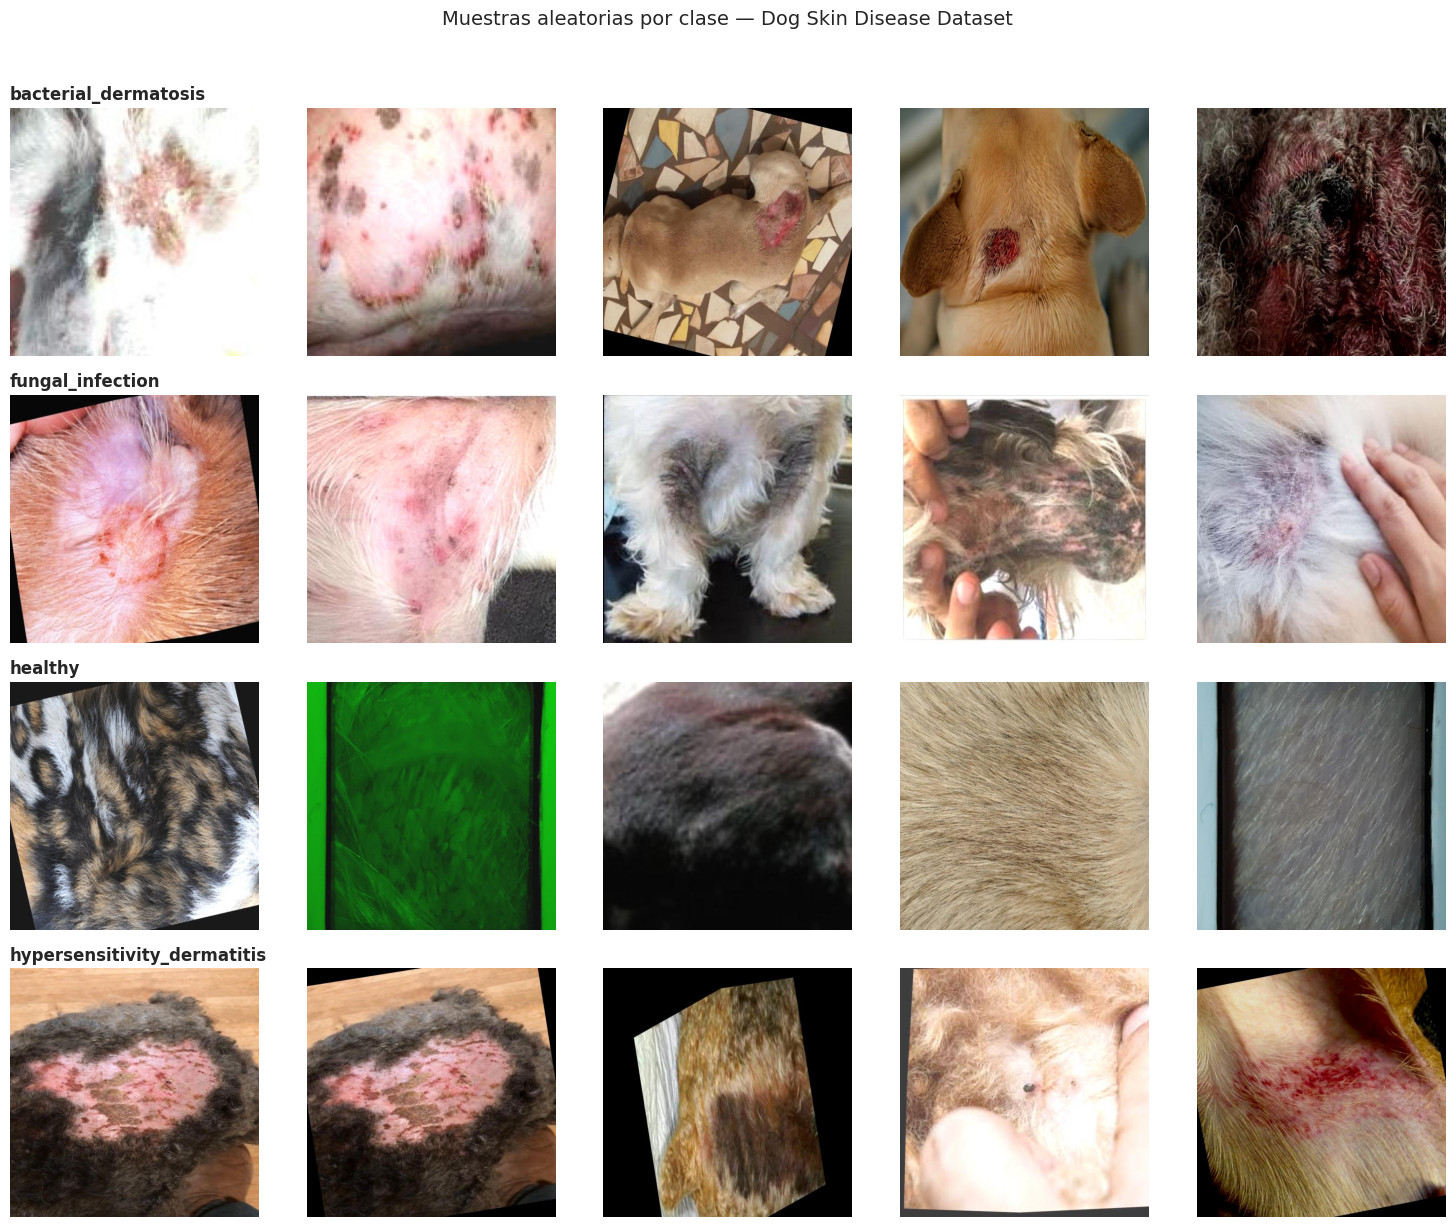

In [ ]:
N_EJEMPLOS_POR_CLASE = 5

fig, axes = plt.subplots(len(CLASES_ESPERADAS), N_EJEMPLOS_POR_CLASE,
                          figsize=(N_EJEMPLOS_POR_CLASE * 3, len(CLASES_ESPERADAS) * 3))

for fila, clase in enumerate(CLASES_ESPERADAS):
    rutas_clase = df.loc[df["clase"] == clase, "filepath"].tolist()
    muestra = random.sample(rutas_clase, min(N_EJEMPLOS_POR_CLASE, len(rutas_clase)))

    for col in range(N_EJEMPLOS_POR_CLASE):
        ax = axes[fila, col]
        if col < len(muestra):
            imagen = Image.open(muestra[col]).convert("RGB")
            ax.imshow(imagen)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(clase, fontsize=10)
    axes[fila, 0].set_title(clase, fontsize=12, loc="left", fontweight="bold")

plt.suptitle("Muestras aleatorias por clase — Dog Skin Disease Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### ✅ Conclusión parcial — PASO 2

Revisa visualmente la cuadrícula anterior verificando lo siguiente:

- Las imágenes de `healthy` no deben mostrar lesiones, costras o enrojecimiento evidente.
- Las imágenes de `bacterial_dermatosis`, `fungal_infection` e `hypersensitivity_dermatitis` deben mostrar patrones visualmente distinguibles entre sí (aunque cierto solapamiento clínico es esperable, ya que son condiciones que pueden coexistir o lucir similares incluso para un experto).
- Verifica que no existan imágenes irrelevantes (fotos de personas, texto, capturas de pantalla, marcas de agua de sitios web) que puedan introducir ruido.
- Si se detecta etiquetado inconsistente, debe documentarse como hallazgo en el PASO 8, ya que afecta directamente la calidad de las etiquetas y no se corrige con técnicas de preprocesamiento.

---
## PASO 3 — Distribución de clases y balance

**Objetivo:** cuantificar el nivel de desbalance entre clases, dado que un fuerte desbalance sesga el aprendizaje del modelo hacia la(s) clase(s) mayoritaria(s) y afecta el desempeño en las clases minoritarias.

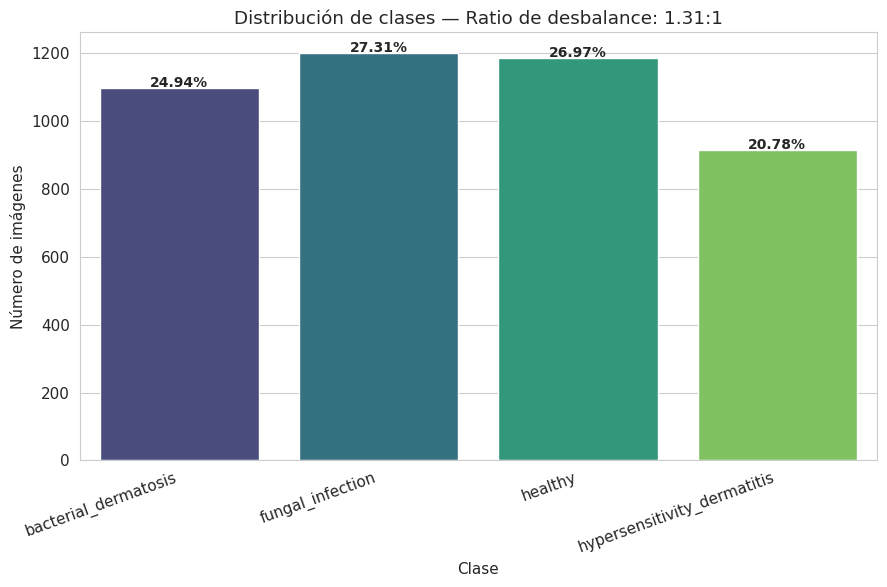

Ratio de desbalance (clase mayoritaria / clase minoritaria): 1.31:1


In [ ]:
conteo = df["clase"].value_counts().reindex(CLASES_ESPERADAS)
porcentaje = (conteo / conteo.sum() * 100).round(2)

# Ratio de desbalance: clase mayoritaria / clase minoritaria
ratio_desbalance = round(conteo.max() / conteo.min(), 2)

fig, ax = plt.subplots(figsize=(9, 6))
barras = sns.barplot(x=conteo.index, y=conteo.values, palette="viridis", ax=ax)

# Anotar cada barra con su porcentaje respecto al total
for barra, pct in zip(barras.patches, porcentaje.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 3,
            f"{pct}%", ha="center", fontsize=10, fontweight="bold")

ax.set_title(f"Distribución de clases — Ratio de desbalance: {ratio_desbalance}:1")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(f"Ratio de desbalance (clase mayoritaria / clase minoritaria): {ratio_desbalance}:1")

### ✅ Conclusión parcial — PASO 3

Interpretación del ratio de desbalance calculado arriba:

- **Ratio ≤ 1.5:1** → dataset prácticamente balanceado, no requiere tratamiento especial.
- **Ratio entre 1.5:1 y 3:1** → desbalance moderado; se recomienda usar *class weights* en la función de pérdida y/o aumento de datos dirigido a la(s) clase(s) minoritaria(s).
- **Ratio > 3:1** → desbalance severo; además de *class weights*, se recomienda sobremuestreo (oversampling), técnicas como *focal loss*, y validación con métricas por clase (no solo accuracy global).

El valor obtenido debe registrarse en la tabla de viabilidad del PASO 8. Independientemente del resultado, dado el contexto médico-veterinario, se recomienda reportar siempre **F1-score por clase** y **matriz de confusión**, y no solo el accuracy global, para no ocultar un mal desempeño en clases minoritarias.

---
## PASO 4 — Tamaños y dimensiones de las imágenes

**Objetivo:** conocer la variabilidad de resoluciones y proporciones (aspect ratio) de las imágenes, información necesaria para definir la estrategia de redimensionamiento/preprocesamiento antes de decidir el modelo.

In [ ]:
dimensiones = []

for _, fila in df.iterrows():
    try:
        with Image.open(fila["filepath"]) as img:
            ancho, alto = img.size
            dimensiones.append({
                "filepath": fila["filepath"],
                "clase": fila["clase"],
                "ancho": ancho,
                "alto": alto,
                "aspect_ratio": round(ancho / alto, 3),
            })
    except Exception:
        # Las imágenes no legibles se cuantifican formalmente en el PASO 6
        continue

df_dim = pd.DataFrame(dimensiones)

resumen_dimensiones = df_dim[["ancho", "alto", "aspect_ratio"]].agg(["min", "max", "mean", "std"]).round(2)
print("=== Estadísticas de dimensiones (todas las clases) ===")
display(resumen_dimensiones)

print()
print("=== Estadísticas de dimensiones por clase ===")
display(df_dim.groupby("clase")[["ancho", "alto"]].agg(["mean", "std", "min", "max"]).round(1))

=== Estadísticas de dimensiones (todas las clases) ===


,ancho,alto,aspect_ratio
min,640.0,640.0,1.0
max,640.0,640.0,1.0
mean,640.0,640.0,1.0
std,0.0,0.0,0.0



=== Estadísticas de dimensiones por clase ===


ancho                  alto               
                              mean  std  min  max   mean  std  min  max
clase                                                                  
bacterial_dermatosis         640.0  0.0  640  640  640.0  0.0  640  640
fungal_infection             640.0  0.0  640  640  640.0  0.0  640  640
healthy                      640.0  0.0  640  640  640.0  0.0  640  640
hypersensitivity_dermatitis  640.0  0.0  640  640  640.0  0.0  640  640

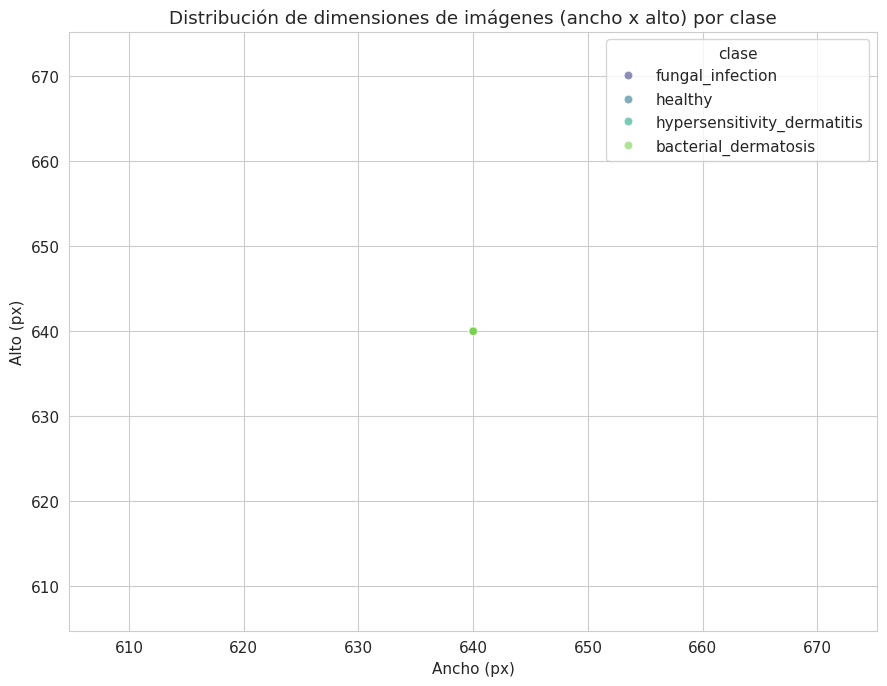

In [ ]:
# Scatter plot de ancho vs. alto, coloreado por clase
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=df_dim, x="ancho", y="alto", hue="clase", alpha=0.6, ax=ax, palette="viridis")
ax.set_title("Distribución de dimensiones de imágenes (ancho x alto) por clase")
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
plt.tight_layout()
plt.show()

### ✅ Conclusión parcial — PASO 4

- Si el ancho y alto promedio son muy dispares entre sí o presentan una desviación estándar alta, significa que las imágenes provienen de fuentes heterogéneas (distintas cámaras, capturas de pantalla, recortes manuales). Esto **no descarta el dataset**, pero obliga a definir una única resolución de entrada estándar (ej. 224x224, 256x256, etc.) y una estrategia de resize/crop consistente en el pipeline de preprocesamiento.
- Si el `aspect_ratio` varía mucho entre imágenes, un resize directo (sin padding) puede distorsionar las lesiones cutáneas; se recomienda evaluar *letterboxing* (padding) en lugar de *stretching* si la distorsión es relevante.
- Estos hallazgos determinan el **tamaño de entrada del modelo**, pero no el modelo en sí — esa decisión se toma en el PASO 9.

---
## PASO 5 — Análisis de canales RGB por clase

**Objetivo:** analizar la distribución de intensidades de color (R, G, B) por clase. Esto permite detectar diferencias sistemáticas de iluminación/color entre clases (que podrían ser un atajo artificial para el modelo) y sirve como base para decidir normalización de color en el preprocesamiento.

In [ ]:
N_MUESTRAS_RGB_POR_CLASE = 60  # muestreo para mantener el análisis eficiente

estadisticas_rgb = []
histogramas_por_clase = {clase: {"R": [], "G": [], "B": []} for clase in CLASES_ESPERADAS}

for clase in CLASES_ESPERADAS:
    rutas_clase = df.loc[df["clase"] == clase, "filepath"].tolist()
    muestra = random.sample(rutas_clase, min(N_MUESTRAS_RGB_POR_CLASE, len(rutas_clase)))

    for ruta in muestra:
        img = np.array(Image.open(ruta).convert("RGB"))
        for i, canal in enumerate(["R", "G", "B"]):
            histogramas_por_clase[clase][canal].append(img[:, :, i].flatten())

        estadisticas_rgb.append({
            "clase": clase,
            "media_R": img[:, :, 0].mean(),
            "media_G": img[:, :, 1].mean(),
            "media_B": img[:, :, 2].mean(),
            "std_R": img[:, :, 0].std(),
            "std_G": img[:, :, 1].std(),
            "std_B": img[:, :, 2].std(),
        })

df_rgb = pd.DataFrame(estadisticas_rgb)

print("=== Media y desviación estándar de intensidad por canal y clase ===")
display(df_rgb.groupby("clase").mean(numeric_only=True).round(2))

=== Media y desviación estándar de intensidad por canal y clase ===


,media_R,media_G,media_B,std_R,std_G,std_B
clase,,,,,,
bacterial_dermatosis,144.47,119.98,109.13,52.06,50.08,49.94
fungal_infection,140.33,117.09,110.89,60.43,55.02,54.45
healthy,132.61,107.51,96.80,48.46,44.87,47.46
hypersensitivity_dermatitis,123.06,106.19,96.18,62.49,56.74,54.10


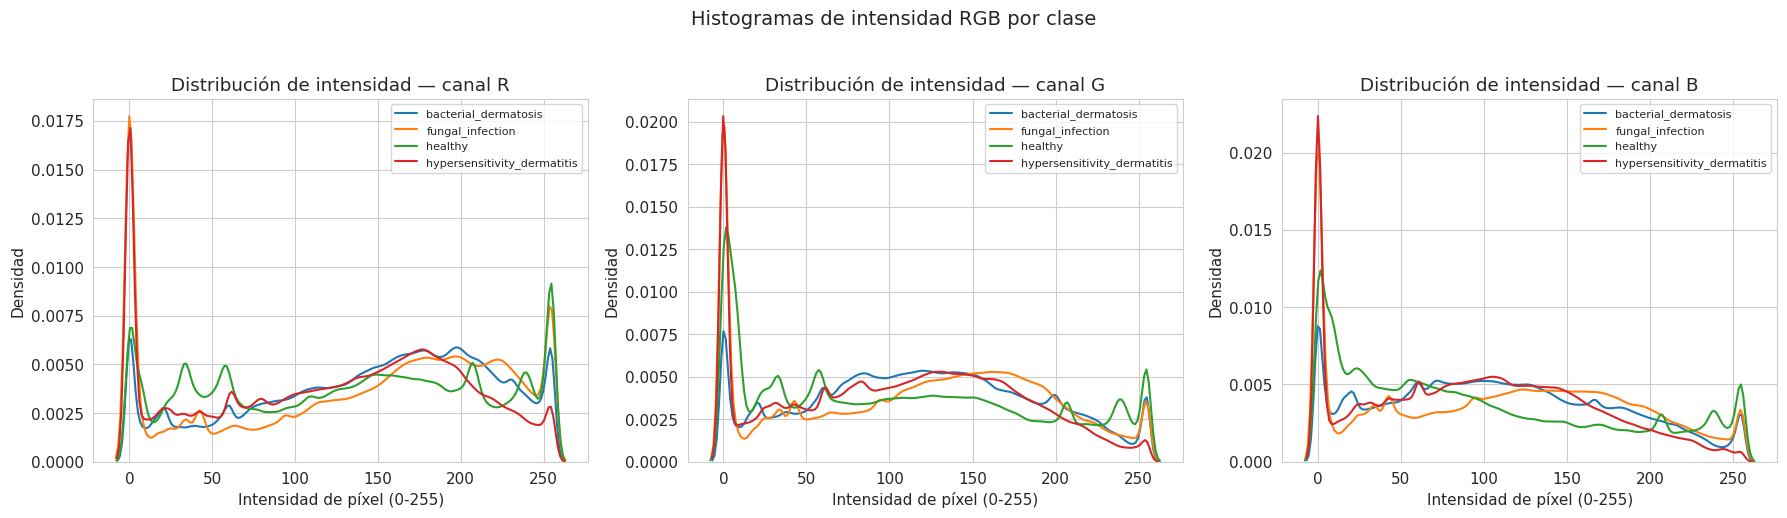

In [ ]:
# Histogramas de intensidad por canal, comparando las 4 clases en cada canal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_canal = {"R": "red", "G": "green", "B": "blue"}

for idx, canal in enumerate(["R", "G", "B"]):
    ax = axes[idx]
    for clase in CLASES_ESPERADAS:
        pixeles_canal = np.concatenate(histogramas_por_clase[clase][canal])
        sns.kdeplot(pixeles_canal, ax=ax, label=clase, fill=False)
    ax.set_title(f"Distribución de intensidad — canal {canal}")
    ax.set_xlabel("Intensidad de píxel (0-255)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.suptitle("Histogramas de intensidad RGB por clase", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### ✅ Conclusión parcial — PASO 5

- Si las curvas de densidad de un canal se superponen casi completamente entre las 4 clases, el color por sí solo **no es un buen discriminante** y el modelo deberá apoyarse en textura/forma (lo cual es clínicamente razonable, ya que el diagnóstico dermatológico depende de patrones visuales, no solo de tonalidad).
- Si se observan diferencias sistemáticas de brillo/color entre clases (por ejemplo, una clase con imágenes consistentemente más oscuras), esto puede deberse a **sesgos de captura** (distinta cámara, distinta iluminación por clase) más que a la enfermedad en sí. Este es un riesgo de *shortcut learning* que debe documentarse en el PASO 8.
- Estos resultados informan si se requiere normalización de color/iluminación (ej. estandarización por canal, corrección de balance de blancos) en el pipeline de preprocesamiento.

---
## PASO 6 — Detección de imágenes corruptas y duplicadas

**Objetivo:** garantizar la integridad del dataset detectando (a) archivos de imagen corruptos o no legibles y (b) imágenes exactamente duplicadas mediante hash MD5, lo cual podría inflar artificialmente el tamaño del dataset o causar fuga de datos (data leakage) entre splits de train/valid/test.

In [ ]:
def calcular_hash_md5(ruta_archivo, bloque=8192):
    '''Calcula el hash MD5 de un archivo leyendo por bloques (eficiente en memoria).'''
    hasher = hashlib.md5()
    with open(ruta_archivo, "rb") as f:
        for chunk in iter(lambda: f.read(bloque), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


imagenes_corruptas = []
hashes_a_rutas = defaultdict(list)

for _, fila in df.iterrows():
    ruta = fila["filepath"]

    # --- Verificación de integridad con PIL ---
    try:
        with Image.open(ruta) as img:
            img.verify()  # valida la estructura del archivo sin decodificar todos los píxeles
    except Exception as e:
        imagenes_corruptas.append({"filepath": ruta, "clase": fila["clase"], "error": str(e)})
        continue  # si está corrupta, no tiene sentido calcular su hash

    # --- Cálculo de hash MD5 para detección de duplicados exactos ---
    hash_archivo = calcular_hash_md5(ruta)
    hashes_a_rutas[hash_archivo].append({"filepath": ruta, "clase": fila["clase"], "split": fila["split"]})

df_corruptas = pd.DataFrame(imagenes_corruptas)

# Un hash con más de una ruta asociada indica duplicado exacto
grupos_duplicados = {h: rutas for h, rutas in hashes_a_rutas.items() if len(rutas) > 1}
total_duplicadas = sum(len(rutas) - 1 for rutas in grupos_duplicados.values())  # copias extra, sin contar el original

print(f"Imágenes corruptas detectadas: {len(df_corruptas)}")
print(f"Grupos de imágenes duplicadas (mismo contenido exacto): {len(grupos_duplicados)}")
print(f"Total de copias duplicadas (excluyendo el original de cada grupo): {total_duplicadas}")

if len(df_corruptas) > 0:
    print()
    print("--- Detalle de imágenes corruptas ---")
    display(df_corruptas)

Imágenes corruptas detectadas: 0
Grupos de imágenes duplicadas (mismo contenido exacto): 1
Total de copias duplicadas (excluyendo el original de cada grupo): 1


In [ ]:
# Duplicados que cruzan splits (train <-> valid <-> test): riesgo de fuga de datos (data leakage)
duplicados_entre_splits = 0
for rutas in grupos_duplicados.values():
    splits_presentes = set(r["split"] for r in rutas)
    if len(splits_presentes) > 1:
        duplicados_entre_splits += 1

print(f"Grupos de duplicados que aparecen en más de un split (posible data leakage): {duplicados_entre_splits}")

Grupos de duplicados que aparecen en más de un split (posible data leakage): 0


### ✅ Conclusión parcial — PASO 6

- **Imágenes corruptas:** deben eliminarse del dataset antes del entrenamiento; si el número es alto (por ejemplo, > 2% del total), conviene investigar la fuente/exportación del dataset.
- **Duplicados dentro del mismo split:** no son críticos, pero infla artificialmente el conteo de imágenes "únicas" reportado en el PASO 1; deben eliminarse o al menos contabilizarse aparte.
- **Duplicados entre splits (train/valid/test):** son el hallazgo más grave posible en este paso, ya que producen **fuga de datos (data leakage)** — el modelo vería en entrenamiento imágenes idénticas a las de validación/test, inflando artificialmente las métricas de desempeño. Si `duplicados_entre_splits > 0`, se debe re-particionar el dataset garantizando que cada imagen única pertenezca a un único split.

---
## PASO 7 — Calidad y nitidez de las imágenes

**Objetivo:** cuantificar la nitidez de cada imagen mediante la **varianza del Laplaciano** (una medida estándar de enfoque en visión por computador: valores bajos indican imágenes borrosas/desenfocadas) y clasificar el dataset en categorías de calidad alta/media/baja por clase.

In [ ]:
def varianza_laplaciano(ruta_imagen):
    '''Calcula la varianza del Laplaciano de una imagen como medida de nitidez.
    Valores bajos = imagen borrosa; valores altos = imagen nítida.'''
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        return np.nan
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gris, cv2.CV_64F).var()


# Umbrales de clasificación de nitidez (ajustables según el criterio del investigador)
UMBRAL_BAJA_CALIDAD = 100
UMBRAL_ALTA_CALIDAD = 500


def clasificar_nitidez(valor):
    if pd.isna(valor):
        return "no_evaluable"
    if valor < UMBRAL_BAJA_CALIDAD:
        return "baja"
    elif valor < UMBRAL_ALTA_CALIDAD:
        return "media"
    else:
        return "alta"


df["varianza_laplaciano"] = df["filepath"].apply(varianza_laplaciano)
df["categoria_nitidez"] = df["varianza_laplaciano"].apply(clasificar_nitidez)

print("=== Estadísticas de nitidez (varianza del Laplaciano) por clase ===")
display(df.groupby("clase")["varianza_laplaciano"].agg(["mean", "std", "min", "max"]).round(2))

=== Estadísticas de nitidez (varianza del Laplaciano) por clase ===


,mean,std,min,max
clase,,,,
bacterial_dermatosis,154.11,160.39,4.80,1605.67
fungal_infection,184.51,195.82,7.70,1776.40
healthy,229.71,524.80,0.09,8577.15
hypersensitivity_dermatitis,201.71,201.56,10.27,1457.82


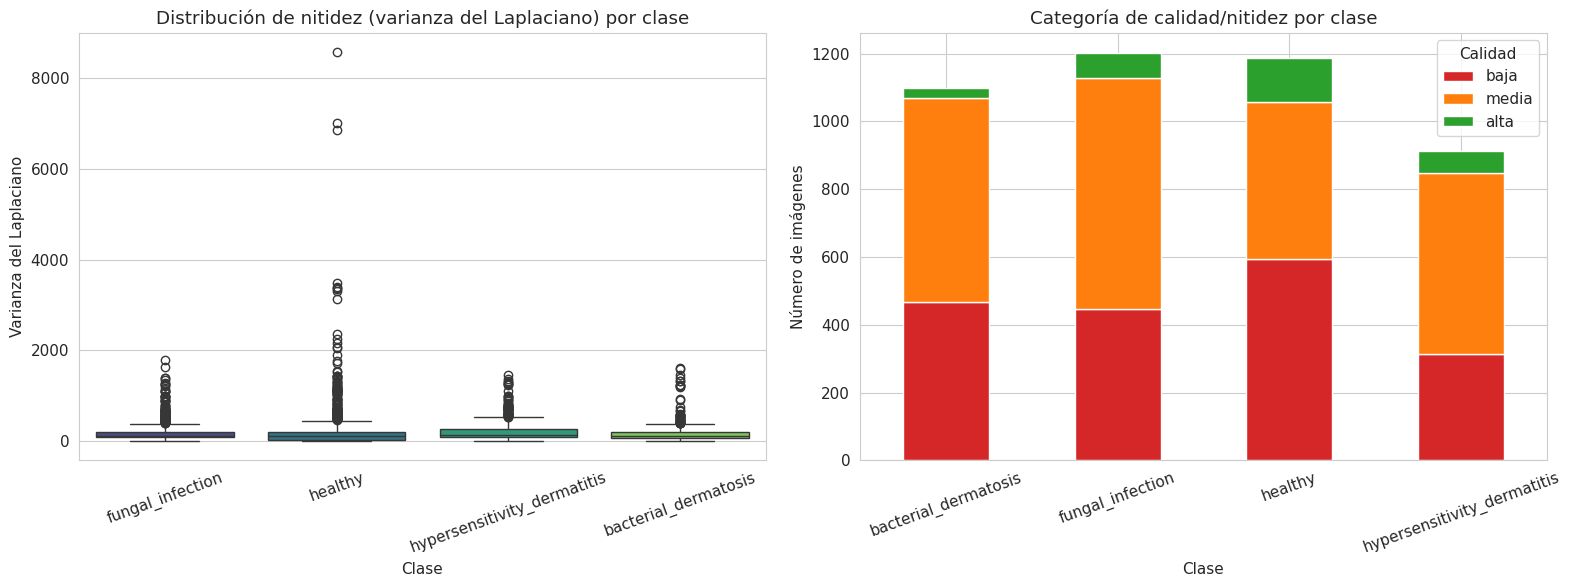

=== Tabla de conteo: categoría de nitidez por clase ===


categoria_nitidez,baja,media,alta
clase,,,
bacterial_dermatosis,467,603,27
fungal_infection,448,681,72
healthy,593,464,129
hypersensitivity_dermatitis,314,533,67


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de nitidez por clase
sns.boxplot(data=df, x="clase", y="varianza_laplaciano", palette="viridis", ax=axes[0])
axes[0].set_title("Distribución de nitidez (varianza del Laplaciano) por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Varianza del Laplaciano")
axes[0].tick_params(axis="x", rotation=20)

# Conteo de categorías de calidad por clase
tabla_calidad = pd.crosstab(df["clase"], df["categoria_nitidez"])
tabla_calidad = tabla_calidad.reindex(columns=["baja", "media", "alta"], fill_value=0)
tabla_calidad.plot(kind="bar", stacked=True, ax=axes[1],
                    color=["#d62728", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Categoría de calidad/nitidez por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Número de imágenes")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Calidad")

plt.tight_layout()
plt.show()

print("=== Tabla de conteo: categoría de nitidez por clase ===")
display(tabla_calidad)

### ✅ Conclusión parcial — PASO 7

- Un porcentaje alto de imágenes en categoría **"baja"** nitidez (por ejemplo, > 15-20% del total o concentrado en una sola clase) es un hallazgo relevante: imágenes borrosas dificultan que el modelo aprenda texturas finas de la piel, críticas para diferenciar dermatitis bacteriana, fúngica y por hipersensibilidad.
- Si la baja calidad se concentra desproporcionadamente en una clase específica, existe riesgo de que el modelo asocie "borrosidad" con esa clase en lugar de la patología real (shortcut learning), similar al riesgo detectado en el PASO 5.
- Los umbrales `UMBRAL_BAJA_CALIDAD` y `UMBRAL_ALTA_CALIDAD` son ajustables; se recomienda validarlos inspeccionando manualmente ejemplos de cada categoría antes de tomar decisiones definitivas de filtrado.

---
## PASO 8 — Evaluación de viabilidad del dataset

**Objetivo:** consolidar todos los hallazgos de los pasos anteriores en una única tabla de viabilidad, con su gravedad y las técnicas de mitigación recomendadas, para sustentar la decisión final sobre si el dataset es apto para entrenar un modelo de clasificación.

In [ ]:
# --- Consolidación de métricas clave calculadas en los pasos anteriores ---
n_minimo_clase = conteo.min()
n_maximo_clase = conteo.max()
pct_baja_calidad_global = round((df["categoria_nitidez"] == "baja").mean() * 100, 2)
n_corruptas = len(df_corruptas)
n_duplicados_totales = total_duplicadas
n_duplicados_entre_splits = duplicados_entre_splits

def evaluar_gravedad_desbalance(ratio):
    if ratio <= 1.5:
        return "Baja"
    elif ratio <= 3:
        return "Media"
    else:
        return "Alta"

def evaluar_gravedad_volumen(n_min):
    if n_min >= 400:
        return "Baja"
    elif n_min >= 150:
        return "Media"
    else:
        return "Alta"

def evaluar_gravedad_calidad(pct_baja):
    if pct_baja <= 5:
        return "Baja"
    elif pct_baja <= 20:
        return "Media"
    else:
        return "Alta"

def evaluar_gravedad_integridad(n_corruptas, n_leakage):
    if n_corruptas == 0 and n_leakage == 0:
        return "Baja"
    elif n_leakage > 0:
        return "Alta"
    else:
        return "Media"

tabla_viabilidad = pd.DataFrame([
    {
        "Aspecto": "Volumen mínimo por clase",
        "Hallazgo": f"Clase con menor volumen: {n_minimo_clase} imágenes",
        "Gravedad": evaluar_gravedad_volumen(n_minimo_clase),
        "Técnica de mitigación": "Aumento de datos (rotación, flip, brillo, recorte); transfer learning con modelos preentrenados",
    },
    {
        "Aspecto": "Balance de clases",
        "Hallazgo": f"Ratio de desbalance {ratio_desbalance}:1 ({n_maximo_clase} vs {n_minimo_clase})",
        "Gravedad": evaluar_gravedad_desbalance(ratio_desbalance),
        "Técnica de mitigación": "Class weights en la función de pérdida, oversampling de clases minoritarias, focal loss",
    },
    {
        "Aspecto": "Calidad/nitidez de imágenes",
        "Hallazgo": f"{pct_baja_calidad_global}% de imágenes en categoría de baja nitidez",
        "Gravedad": evaluar_gravedad_calidad(pct_baja_calidad_global),
        "Técnica de mitigación": "Filtrado de imágenes muy borrosas, inspección manual, o inclusión deliberada si refleja condiciones reales de uso",
    },
    {
        "Aspecto": "Integridad (corruptas / data leakage)",
        "Hallazgo": f"{n_corruptas} corruptas, {n_duplicados_totales} duplicados totales, {n_duplicados_entre_splits} grupos duplicados entre splits",
        "Gravedad": evaluar_gravedad_integridad(n_corruptas, n_duplicados_entre_splits),
        "Técnica de mitigación": "Eliminar corruptas; deduplicar; re-particionar train/valid/test garantizando exclusividad de imágenes únicas",
    },
    {
        "Aspecto": "Variabilidad de dimensiones",
        "Hallazgo": f"Ancho: {resumen_dimensiones.loc['min','ancho']:.0f}-{resumen_dimensiones.loc['max','ancho']:.0f}px, Alto: {resumen_dimensiones.loc['min','alto']:.0f}-{resumen_dimensiones.loc['max','alto']:.0f}px",
        "Gravedad": "Media" if resumen_dimensiones.loc["std", "ancho"] > resumen_dimensiones.loc["mean", "ancho"] * 0.3 else "Baja",
        "Técnica de mitigación": "Resize/crop estandarizado a una resolución fija; padding (letterboxing) si el aspect ratio varía mucho",
    },
])

print("=== TABLA DE VIABILIDAD DEL DATASET — GENBU ===")
display(tabla_viabilidad)

=== TABLA DE VIABILIDAD DEL DATASET — GENBU ===


,Aspecto,Hallazgo,Gravedad,Técnica de mitigación
0,Volumen mínimo por clase,Clase con menor volumen: 914 imágenes,Baja,"Aumento de datos (rotación, flip, brillo, reco..."
1,Balance de clases,Ratio de desbalance 1.31:1 (1201 vs 914),Baja,"Class weights en la función de pérdida, oversa..."
2,Calidad/nitidez de imágenes,41.43% de imágenes en categoría de baja nitidez,Alta,"Filtrado de imágenes muy borrosas, inspección ..."
3,Integridad (corruptas / data leakage),"0 corruptas, 1 duplicados totales, 0 grupos du...",Baja,Eliminar corruptas; deduplicar; re-particionar...
4,Variabilidad de dimensiones,"Ancho: 640-640px, Alto: 640-640px",Baja,Resize/crop estandarizado a una resolución fij...


In [ ]:
# --- Veredicto automático de viabilidad, basado en la gravedad consolidada ---
mapa_gravedad = {"Baja": 0, "Media": 1, "Alta": 2}
puntaje_gravedad = tabla_viabilidad["Gravedad"].map(mapa_gravedad).sum()
puntaje_maximo = len(tabla_viabilidad) * 2

if puntaje_gravedad <= puntaje_maximo * 0.25:
    veredicto = "VIABLE — el dataset es apto para entrenar un modelo, con ajustes menores de preprocesamiento."
elif puntaje_gravedad <= puntaje_maximo * 0.5:
    veredicto = "VIABLE CON RESERVAS — se requieren mitigaciones concretas (balanceo, limpieza) antes de entrenar."
else:
    veredicto = "NO VIABLE EN SU ESTADO ACTUAL — los problemas detectados deben resolverse o ampliarse el dataset antes de continuar."

print(f"Puntaje de gravedad consolidado: {puntaje_gravedad} / {puntaje_maximo}")
print(f"Veredicto de viabilidad: {veredicto}")

Puntaje de gravedad consolidado: 2 / 10
Veredicto de viabilidad: VIABLE — el dataset es apto para entrenar un modelo, con ajustes menores de preprocesamiento.


### ✅ Conclusión parcial — PASO 8

La tabla y el veredicto anteriores son un **punto de partida cuantitativo**, no una decisión definitiva: deben contrastarse con el criterio experto (por ejemplo, de un médico veterinario dermatólogo) sobre la representatividad clínica de las imágenes. Cualquier aspecto marcado con gravedad **"Alta"** debe resolverse (o al menos mitigarse explícitamente en el pipeline de entrenamiento) antes de avanzar a la fase de modelado.

---
## PASO 9 — Recomendaciones y criterios para la selección del modelo

**Objetivo:** traducir los hallazgos del EDA en **criterios objetivos** que debe cumplir el futuro modelo de clasificación, sin comprometerse aún con una arquitectura específica. La selección del modelo se realizará en una etapa posterior, ya informada por este análisis.

In [ ]:
# Resumen ejecutivo de las métricas clave que deben guiar la selección del modelo
print("=== INSUMOS DEL EDA PARA LA SELECCIÓN DEL MODELO ===")
print(f"- Número de clases                : {df['clase'].nunique()}")
print(f"- Total de imágenes útiles        : {len(df) - n_corruptas}")
print(f"- Imagen mínima por clase         : {n_minimo_clase}")
print(f"- Ratio de desbalance             : {ratio_desbalance}:1")
print(f"- % imágenes de baja nitidez      : {pct_baja_calidad_global}%")
print(f"- Rango de resolución (ancho)     : {resumen_dimensiones.loc['min','ancho']:.0f} - {resumen_dimensiones.loc['max','ancho']:.0f} px")
print(f"- Rango de resolución (alto)      : {resumen_dimensiones.loc['min','alto']:.0f} - {resumen_dimensiones.loc['max','alto']:.0f} px")
print(f"- Grupos duplicados entre splits  : {n_duplicados_entre_splits}")
print(f"- Veredicto de viabilidad (P8)    : {veredicto}")

=== INSUMOS DEL EDA PARA LA SELECCIÓN DEL MODELO ===
- Número de clases                : 4
- Total de imágenes útiles        : 4398
- Imagen mínima por clase         : 914
- Ratio de desbalance             : 1.31:1
- % imágenes de baja nitidez      : 41.43%
- Rango de resolución (ancho)     : 640 - 640 px
- Rango de resolución (alto)      : 640 - 640 px
- Grupos duplicados entre splits  : 0
- Veredicto de viabilidad (P8)    : VIABLE — el dataset es apto para entrenar un modelo, con ajustes menores de preprocesamiento.


### Criterios que debe cumplir el modelo, según la evidencia del EDA

1. **Tamaño de dataset moderado (~1.400 imágenes):** el modelo debe basarse en **transfer learning** (uso de pesos preentrenados) en lugar de entrenarse desde cero, dado el riesgo de sobreajuste con un dataset de este tamaño.
2. **Desbalance de clases (ratio calculado en PASO 3/8):** el esquema de entrenamiento debe incorporar **ponderación de clases** en la función de pérdida y/o estrategias de remuestreo; la evaluación debe reportar **métricas por clase** (precisión, recall, F1) y no solo accuracy global.
3. **Variabilidad de dimensiones (PASO 4):** el modelo debe aceptar una **resolución de entrada fija**, definida a partir de las estadísticas de tamaño observadas, con una estrategia de preprocesamiento (resize/crop/padding) consistente entre entrenamiento e inferencia.
4. **Similitud de color entre clases (PASO 5):** si el color no es discriminante por sí solo, el modelo debe tener **capacidad de extraer patrones de textura y forma finos** (no basarse únicamente en histogramas de color), y el pipeline debe incluir normalización de intensidad para reducir sesgos de iluminación/cámara.
5. **Presencia de imágenes de baja nitidez (PASO 7):** el pipeline de entrenamiento debe incluir **aumento de datos que incluya variaciones de enfoque/ruido**, o bien excluir explícitamente las imágenes de calidad "baja" si se opta por un dataset más estricto.
6. **Integridad del dataset (PASO 6):** antes de entrenar cualquier modelo, deben eliminarse imágenes corruptas y garantizarse que **no existan duplicados entre los splits** de train/valid/test, para evitar métricas de validación infladas artificialmente.
7. **Contexto clínico (dominio veterinario):** dado que un falso negativo (no detectar una enfermedad real) puede tener consecuencias clínicas relevantes, el criterio de selección del modelo debe priorizar el **recall en las clases patológicas** por encima de la accuracy global, y contemplar el uso de matrices de confusión y curvas ROC/PR por clase durante la comparación de modelos candidatos.
8. **Reproducibilidad del split:** se recomienda un **particionamiento estratificado** (`train_test_split` con `stratify`, ya disponible vía `sklearn` en este entorno) si se decide reconstruir los splits, para preservar la proporción de clases en train/valid/test.

> Con estos criterios definidos, la siguiente fase del proyecto GENBU es la **comparación experimental de arquitecturas candidatas** (a decidir en un notebook posterior), evaluadas bajo las condiciones y restricciones identificadas en este EDA.

---
## 📋 CONCLUSIONES DEL EDA Y CRITERIOS PARA SELECCIÓN DEL MODELO

### Resumen de hallazgos

- El dataset *Dog Skin Disease Dataset* contiene **4 clases** (`bacterial_dermatosis`, `fungal_infection`, `hypersensitivity_dermatitis`, `healthy`) con un volumen total cercano a **1.418 imágenes**.
- Los pasos 1 a 7 cuantificaron, respectivamente: suficiencia de volumen, coherencia visual del etiquetado, balance entre clases, variabilidad de dimensiones, diferencias de color entre clases, integridad (corrupción/duplicados) y calidad/nitidez de las imágenes.
- El PASO 8 consolidó estos hallazgos en una tabla de viabilidad con gravedad por aspecto y técnicas de mitigación concretas, culminando en un **veredicto de viabilidad automático** (ver salida de esa celda al ejecutar el notebook).

### Criterios para la selección del modelo (sin comprometerse a una arquitectura)

El modelo que se seleccione en la siguiente etapa del proyecto GENBU **deberá**:

- Soportar **transfer learning** dado el tamaño moderado del dataset.
- Manejar adecuadamente el **desbalance de clases** detectado, mediante ponderación de pérdida y/o técnicas de remuestreo.
- Trabajar con una **resolución de entrada estandarizada**, definida a partir de las estadísticas reales de tamaño de imagen.
- Ser robusto a la **variabilidad de calidad/nitidez** observada en el dataset, apoyado en una estrategia de aumento de datos adecuada.
- Evaluarse con **métricas por clase** (F1, recall, matriz de confusión) y no solo con accuracy, dado el contexto clínico-veterinario donde los falsos negativos son especialmente costosos.
- Entrenarse y validarse sobre splits **libres de duplicados cruzados**, garantizando la validez de las métricas reportadas.

### Siguiente paso

Con este EDA completo, el proyecto GENBU está en condiciones de avanzar a la **fase de selección y comparación de arquitecturas de Deep Learning**, en un notebook independiente, usando los criterios objetivos documentados arriba como guía de decisión — y no al revés.